## Load Dataset from Kaggle - Beijing PM2.5 Dataset

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("djhavera/beijing-pm25-data-data-set")

print("Path to dataset files:", path)

100%|██████████| 505k/505k [00:00<00:00, 647kB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/djhavera/beijing-pm25-data-data-set/versions/1


In [5]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

sns.set(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)


df = pd.read_csv(os.path.join(path, os.listdir(path)[0]))

print("Dataset Loaded. Shape:", df.shape)

Dataset Loaded. Shape: (43824, 13)


## Review of Dataset

No      : Row index (not useful for modeling) \
year    : Year of observation\
month   : Month (captures seasonal trends)\
day     : Day of month\
hour    : Hour of day (captures daily patterns)\
TEMP    : Temperature (°C) → affects pollution dispersion\
DEWP    : Dew point (°C) → indicates humidity level\
PRES    : Atmospheric pressure (hPa) → high pressure traps pollution\
cbwd    : Wind direction (categorical, e.g., NW, SE)\
Iws     : Wind speed → higher wind reduces pollution\
Is      : Snow hours → helps remove pollutants\
Ir      : Rain hours → washes out pollution

pm2.5   : Target variable → air pollution level (µg/m³)

In [6]:
df.head(5)

,No,year,month,day,hour,pm2.5,DEWP,TEMP,PRES,cbwd,Iws,Is,Ir
0,1,2010,1,1,0,NaN,-21,-11.0,1021.0,NW,1.79,0,0
1,2,2010,1,1,1,NaN,-21,-12.0,1020.0,NW,4.92,0,0
2,3,2010,1,1,2,NaN,-21,-11.0,1019.0,NW,6.71,0,0
3,4,2010,1,1,3,NaN,-21,-14.0,1019.0,NW,9.84,0,0
4,5,2010,1,1,4,NaN,-20,-12.0,1018.0,NW,12.97,0,0


## Data Cleaning (Interpolating & Encoding)

In [11]:
from sklearn.preprocessing import LabelEncoder

# 1. Create a proper datetime column and set it as index
df['datetime'] = pd.to_datetime(df[['year', 'month', 'day', 'hour']])
df = df.set_index('datetime').sort_index()

# 2. Handle missing values in time series using time-based interpolation
df['pm2.5'] = df['pm2.5'].interpolate(method='time')

# Drop any remaining rows with missing values
df = df.dropna()

# 3. Convert categorical wind direction (cbwd) into numerical values
le = LabelEncoder()
df['cbwd_encoded'] = le.fit_transform(df['cbwd'])

print("Data cleaned. Total missing values:", df.isna().sum().sum())
display(df.head())

Data cleaned. Total missing values: 0


,No,year,month,day,hour,pm2.5,DEWP,TEMP,PRES,cbwd,Iws,Is,Ir,cbwd_encoded
datetime,,,,,,,,,,,,,,
2010-01-02 00:00:00,25,2010,1,2,0,129.0,-16,-4.0,1020.0,SE,1.79,0,0,2
2010-01-02 01:00:00,26,2010,1,2,1,148.0,-15,-4.0,1020.0,SE,2.68,0,0,2
2010-01-02 02:00:00,27,2010,1,2,2,159.0,-11,-5.0,1021.0,SE,3.57,0,0,2
2010-01-02 03:00:00,28,2010,1,2,3,181.0,-7,-5.0,1022.0,SE,5.36,1,0,2
2010-01-02 04:00:00,29,2010,1,2,4,138.0,-7,-5.0,1022.0,SE,6.25,2,0,2


## Visualising

/tmp/ipykernel_7169/4190308152.py:3: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  df['pm2.5'].resample('M').mean().plot(color='#d62728', linewidth=2)


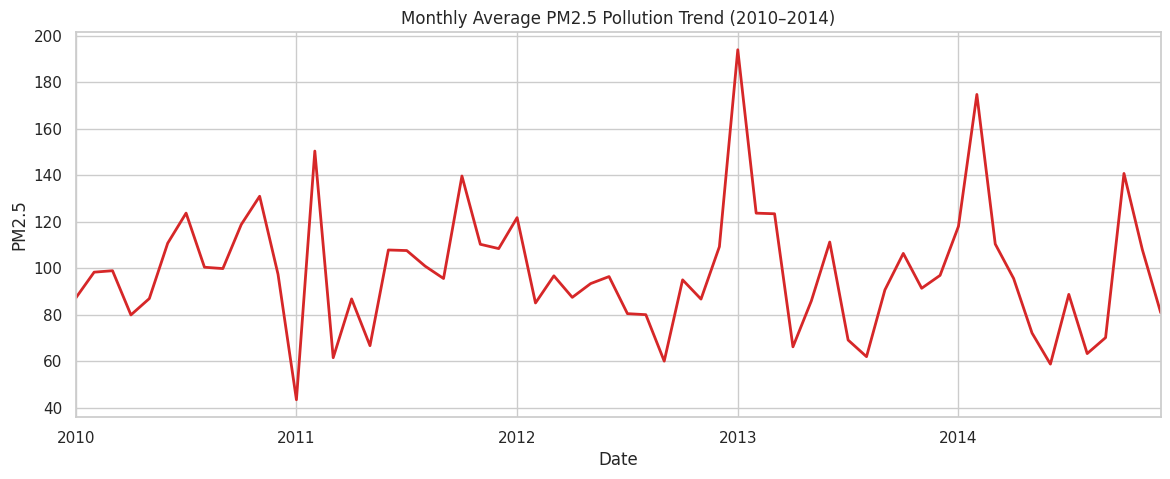

In [13]:
# Plot 1: Monthly Trend
plt.figure(figsize=(14, 5))
df['pm2.5'].resample('M').mean().plot(color='#d62728', linewidth=2)
plt.title('Monthly Average PM2.5 Pollution Trend (2010–2014)')
plt.ylabel('PM2.5')
plt.xlabel('Date')
plt.show()

/tmp/ipykernel_7169/279093618.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=hourly_avg.index, y=hourly_avg.values, palette='viridis')


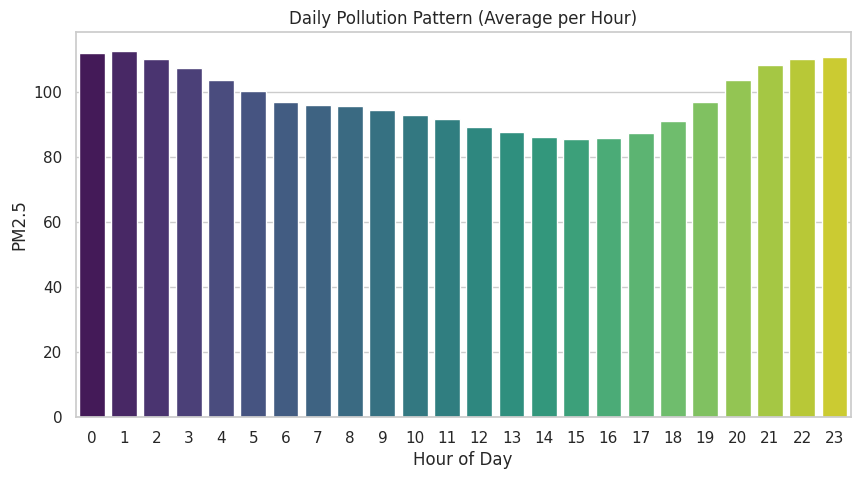

In [14]:
# Plot 2: Daily Pattern (Hourly Average)
plt.figure(figsize=(10, 5))
hourly_avg = df.groupby(df.index.hour)['pm2.5'].mean()
sns.barplot(x=hourly_avg.index, y=hourly_avg.values, palette='viridis')
plt.title('Daily Pollution Pattern (Average per Hour)')
plt.xlabel('Hour of Day')
plt.ylabel('PM2.5')
plt.show()

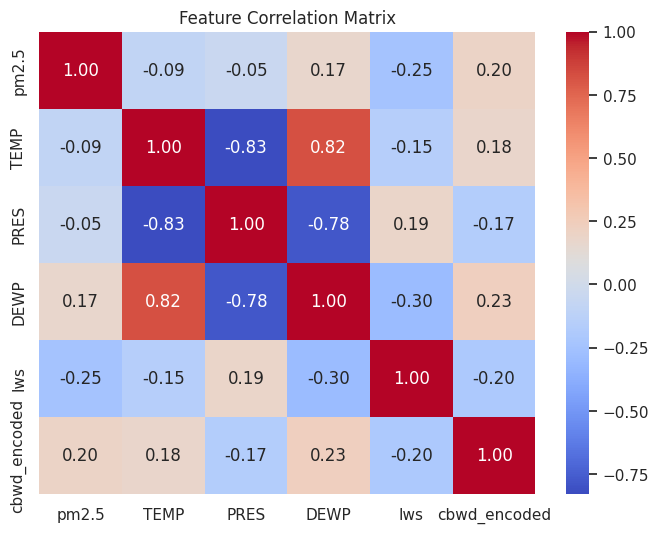

In [15]:
# Plot 3: Correlation Heatmap
plt.figure(figsize=(8, 6))
cols = ['pm2.5', 'TEMP', 'PRES', 'DEWP', 'Iws', 'cbwd_encoded']
sns.heatmap(df[cols].corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Feature Correlation Matrix')
plt.show()

## Selecting Top 6 Features to train the model

/tmp/ipykernel_7169/860563681.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='F_Score', y='Feature', data=ranking, palette='magma')


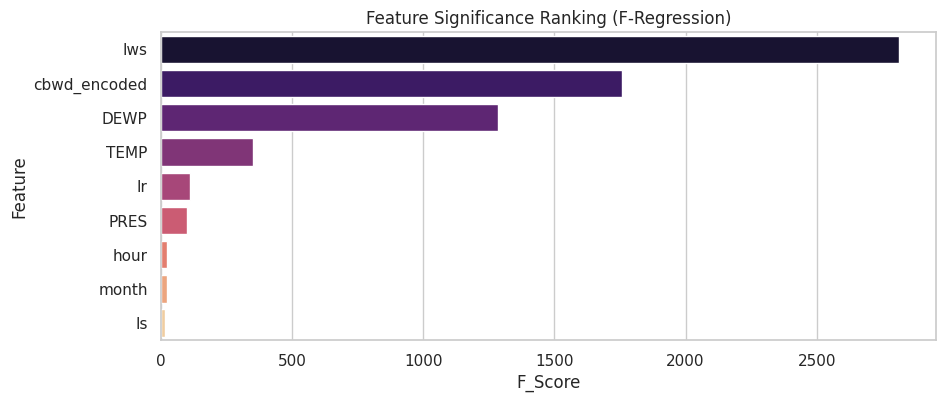

Selected Features: ['Iws', 'cbwd_encoded', 'DEWP', 'TEMP', 'Ir', 'PRES']


In [17]:
from sklearn.feature_selection import SelectKBest, f_regression

# Define candidate features
candidate_features = ['TEMP', 'PRES', 'DEWP', 'Iws', 'Is', 'Ir', 'cbwd_encoded', 'month', 'hour']
X_all = df[candidate_features]
y = df['pm2.5']

# Compute F-scores using regression
selector = SelectKBest(score_func=f_regression, k='all')
selector.fit(X_all, y)

# Display feature ranking
ranking = pd.DataFrame({
    'Feature': candidate_features,
    'F_Score': selector.scores_
}).sort_values(by='F_Score', ascending=False).reset_index(drop=True)

# Visualize feature importance ranking
plt.figure(figsize=(10, 4))
sns.barplot(x='F_Score', y='Feature', data=ranking, palette='magma')
plt.title('Feature Significance Ranking (F-Regression)')
plt.show()

# Select top 5 features
top_features = ranking['Feature'].head(6).tolist()
print("Selected Features:", top_features)

In [21]:
# Prepare final dataset
X_final = df[top_features]
y_final = df['pm2.5']
X_final.head()

,Iws,cbwd_encoded,DEWP,TEMP,Ir,PRES
datetime,,,,,,
2010-01-02 00:00:00,1.79,2,-16,-4.0,0,1020.0
2010-01-02 01:00:00,2.68,2,-15,-4.0,0,1020.0
2010-01-02 02:00:00,3.57,2,-11,-5.0,0,1021.0
2010-01-02 03:00:00,5.36,2,-7,-5.0,0,1022.0
2010-01-02 04:00:00,6.25,2,-7,-5.0,0,1022.0


In [22]:
y.head()

,pm2.5
datetime,
2010-01-02 00:00:00,129.0
2010-01-02 01:00:00,148.0
2010-01-02 02:00:00,159.0
2010-01-02 03:00:00,181.0
2010-01-02 04:00:00,138.0


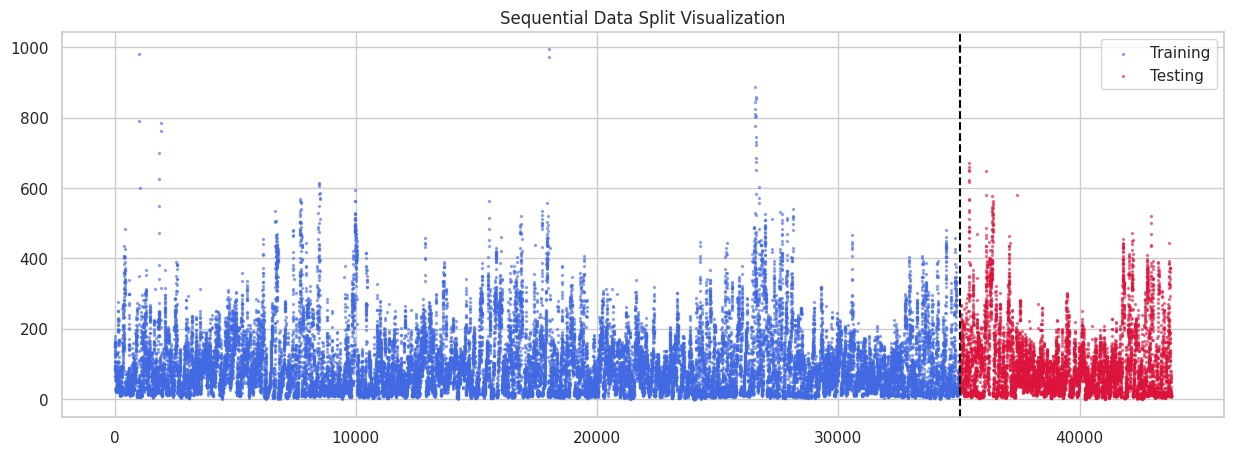

In [25]:
from sklearn.preprocessing import MinMaxScaler

# Sequential train-test split (80:20) without shuffling (important for time series)
X_train, X_test, y_train, y_test = train_test_split(
    X_final, y_final, test_size=0.2, shuffle=False
)

# Apply Min-Max scaling
scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


# Visualize train-test split
plt.figure(figsize=(15, 5))
plt.scatter(range(len(y_train)), y_train, color='royalblue', s=2, alpha=0.5, label='Training')
plt.scatter(range(len(y_train), len(y_train) + len(y_test)), y_test,
            color='crimson', s=2, alpha=0.5, label='Testing')

# Vertical line to show split point
plt.axvline(x=len(y_train), color='black', linestyle='--')

plt.title('Sequential Data Split Visualization')
plt.legend()
plt.show()

## Checking model - Random Forest

In [33]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

rf = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train_scaled, y_train)
y_pred_rf = rf.predict(X_test_scaled)

In [34]:
print("Random Forest Metrics:")
print("MSE:", mean_squared_error(y_test, y_pred_rf))
print("MAE:", mean_absolute_error(y_test, y_pred_rf))
print("R2 Score:", r2_score(y_test, y_pred_rf))

Random Forest Metrics:
MSE: 6649.504006545469
MAE: 56.23213218709196
R2 Score: 0.24457650630111605


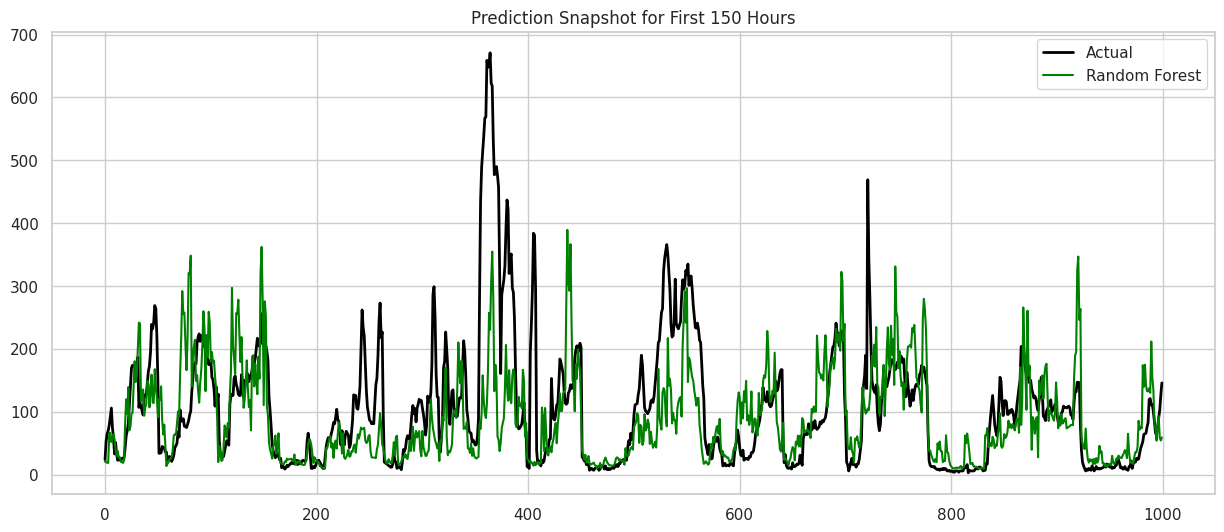

In [37]:
# 1. Prediction Line Chart (First 1000 Hours Sample)
limit = 1000
plt.figure(figsize=(15, 6))
plt.plot(y_test.values[:limit], label='Actual', color='black', linewidth=2)
plt.plot(y_pred_rf[:limit], label='Random Forest', linestyle='-', color='green')
plt.title('Prediction Snapshot for First 150 Hours')
plt.legend()
plt.show()

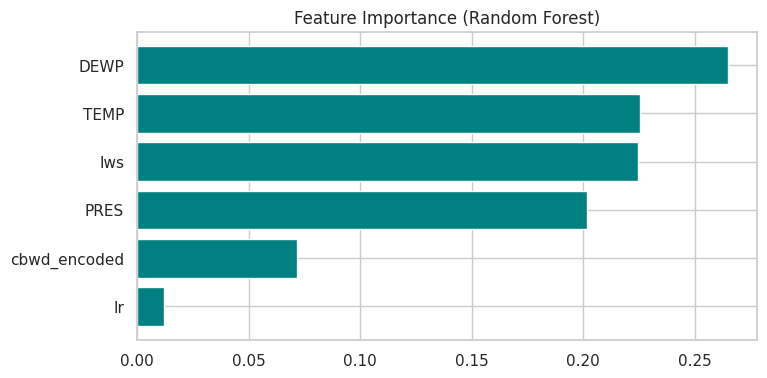

In [38]:
# 2. Feature Importance (Random Forest)
imp_df = pd.DataFrame({
    'Feature': top_features,
    'Importance': rf.feature_importances_
}).sort_values(by='Importance', ascending=True)

plt.figure(figsize=(8, 4))
plt.barh(imp_df['Feature'], imp_df['Importance'], color='teal')
plt.title('Feature Importance (Random Forest)')
plt.show()

## Checking Model - Neural ODE

In [39]:
!pip install torchdiffeq

In [ ]:
import numpy as np
import torch

# Convert to numpy
X_np = X_train_scaled
y_np = y_train.values

# Create sequences (window size)
SEQ_LEN = 24  # 24 hours

def create_sequences(X, y, seq_len):
    X_seq, y_seq = [], []
    for i in range(len(X) - seq_len):
        X_seq.append(X[i:i+seq_len])
        y_seq.append(y[i+seq_len])
    return np.array(X_seq), np.array(y_seq)

X_seq, y_seq = create_sequences(X_np, y_np, SEQ_LEN)

# Convert to torch tensors
X_seq = torch.tensor(X_seq, dtype=torch.float32)
y_seq = torch.tensor(y_seq, dtype=torch.float32).unsqueeze(-1)

In [ ]:
import torch.nn as nn
from torchdiffeq import odeint

# ODE function (dx/dt = f(x))
class ODEFunc(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(dim, 64),
            nn.Tanh(),
            nn.Linear(64, dim)
        )

    def forward(self, t, x):
        return self.net(x)


# Neural ODE model
class NeuralODE(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.func = ODEFunc(input_dim)
        self.fc = nn.Linear(input_dim, 1)

    def forward(self, x):
        # Use last timestep as initial state
        x0 = x[:, -1, :]

        t = torch.linspace(0, 1, steps=10)
        out = odeint(self.func, x0, t)

        # Take final state
        out = out[-1]
        return self.fc(out)

In [ ]:
model = NeuralODE(input_dim=X_seq.shape[2])
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
loss_fn = nn.MSELoss()

EPOCHS = 10

for epoch in range(EPOCHS):
    model.train()

    pred = model(X_seq)
    loss = loss_fn(pred, y_seq)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    print(f"Epoch {epoch+1}, Loss: {loss.item():.4f}")

In [ ]:
# Prepare test sequences
X_test_np = X_test_scaled
y_test_np = y_test.values

X_test_seq, y_test_seq = create_sequences(X_test_np, y_test_np, SEQ_LEN)

X_test_seq = torch.tensor(X_test_seq, dtype=torch.float32)
y_test_seq = torch.tensor(y_test_seq, dtype=torch.float32)

# Predict
model.eval()
with torch.no_grad():
    y_pred_ode = model(X_test_seq).squeeze().numpy()

In [ ]:
print("Neural ODE Metrics:")
print("MSE:", mean_squared_error(y_test_seq.numpy(), y_pred_ode))
print("MAE:", mean_absolute_error(y_test_seq.numpy(), y_pred_ode))
print("R2 Score:", r2_score(y_test_seq.numpy(), y_pred_ode))

In [ ]:
import matplotlib.pyplot as plt

limit = 1000

plt.figure(figsize=(15, 6))
plt.plot(y_test_seq.numpy()[:limit], label='Actual', color='black')
plt.plot(y_pred_ode[:limit], label='Neural ODE', linestyle='--', color='purple')

plt.title('Neural ODE Prediction (First 100 Samples)')
plt.legend()
plt.show()